### Imports

In [1]:
from fundus_dataset import AugmentPair, FundusVesselDataset, CenterCropPair
from torch.utils.data import DataLoader
import torch.nn as nn
import torch
import matplotlib.pyplot as plt
from torch.utils.data import Subset
from torch.utils.data import random_split


### Testing the Dataset

In [2]:
# -------------------------
# Paths
# -------------------------

img_dir = "fundus/train/Original/"
mask_dir = "fundus/train/Ground truth"

# -------------------------
# Dataset
# -------------------------

train_full = FundusVesselDataset(
    img_dir=img_dir,
    mask_dir=mask_dir,
    transform=AugmentPair(crop_size=(512, 512)),
)

val_full = FundusVesselDataset(
    img_dir=img_dir,
    mask_dir=mask_dir,
    transform=CenterCropPair(crop_size=(512, 512)),  # or ResizePair
)

# We need this to find which indices to split the dataset into train and validation
num_samples = len(train_full)

# Set to None to use the whole dataset
sample_size = 32

generator = torch.Generator().manual_seed(42)
indices = torch.randperm(num_samples, generator=generator).tolist()

# Globally restrict dataset size first
if sample_size is not None:
    sample_size = min(sample_size, num_samples)
    indices = indices[:sample_size]

train_size = int(0.8 * len(indices))
train_indices = indices[:train_size]
val_indices = indices[train_size:]

train_dataset = Subset(train_full, train_indices)
val_dataset = Subset(val_full, val_indices)

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=4,
    pin_memory=torch.cuda.is_available(),
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=4,
    pin_memory=torch.cuda.is_available(),
)

# Print out number of samples in train and validation
print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")

# -------------------------
# Debug shape check
# -------------------------

images, masks = next(iter(train_loader))
val_images, val_masks = next(iter(val_loader))

print("Images shape:", images.shape)
print("Masks shape:", masks.shape)
print("Images dtype:", images.dtype)
print("Masks dtype:", masks.dtype)
print("Image min/max:", images.min().item(), images.max().item())
print("Mask unique values:", torch.unique(masks))

print("Val Images shape:", val_images.shape)
print("Val Masks shape:", val_masks.shape)
print("Val Images dtype:", val_images.dtype)
print("Val Masks dtype:", val_masks.dtype)
print("Val Image min/max:", val_images.min().item(), val_images.max().item())
print("Val Mask unique values:", torch.unique(val_masks))


Train dataset size: 25
Validation dataset size: 7


Images shape: torch.Size([8, 3, 512, 512])
Masks shape: torch.Size([8, 1, 512, 512])
Images dtype: torch.float32
Masks dtype: torch.float32
Image min/max: 0.0 1.0
Mask unique values: tensor([0., 1.])
Val Images shape: torch.Size([7, 3, 512, 512])
Val Masks shape: torch.Size([7, 1, 512, 512])
Val Images dtype: torch.float32
Val Masks dtype: torch.float32
Val Image min/max: 0.0 1.0
Val Mask unique values: tensor([0., 1.])


### Matplotlib to test out the DataLoader

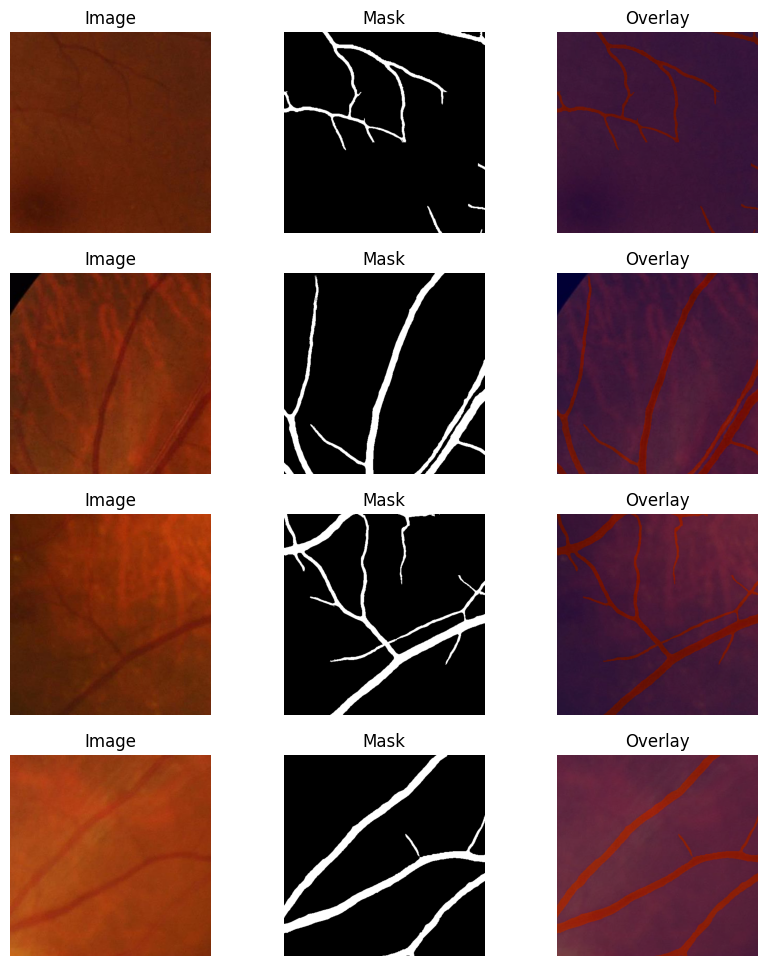

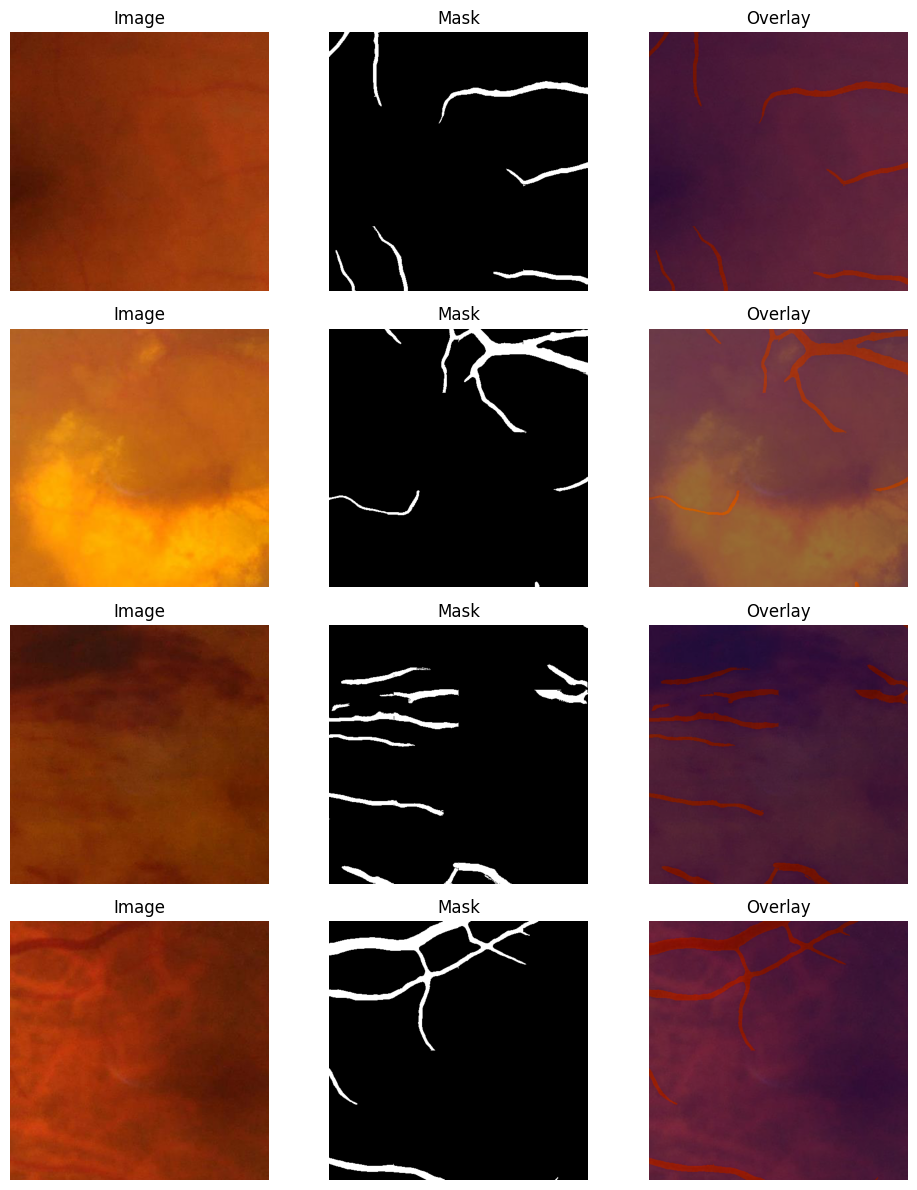

In [3]:
from matplotlib import pyplot as plt

def plot_images(images, masks): 
    fig, axes = plt.subplots(4, 3, figsize=(10, 12))

    for i in range(4):
        img = images[i].permute(1, 2, 0).cpu().numpy()
        mask = masks[i].squeeze(0).cpu().numpy()

        axes[i, 0].imshow(img)
        axes[i, 0].set_title("Image")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(mask, cmap="gray")
        axes[i, 1].set_title("Mask")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(img)
        axes[i, 2].imshow(mask, cmap="jet", alpha=0.4)
        axes[i, 2].set_title("Overlay")
        axes[i, 2].axis("off")

# Plot the training images and masks
plot_images(images, masks)

# Plot the validation images and masks
plot_images(val_images, val_masks)

plt.tight_layout()
plt.show()

### U-Net Training Code

In [4]:
from monai.networks.nets import UNet
from monai.losses import DiceLoss, SoftclDiceLoss
from monai.metrics import DiceMetric
from safetensors.torch import save_model
from datetime import datetime
import torch.nn as nn
import torch
import os
import json

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet(
    spatial_dims=2,
    in_channels=3,
    out_channels=1,
    channels=(16, 32, 64, 128, 256),
    strides=(2, 2, 2, 2),
    num_res_units=2,
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
epochs = 3

dice_loss = DiceLoss(sigmoid=True)
cldice_loss = SoftclDiceLoss()
bce_loss = nn.BCEWithLogitsLoss()
hard_dice_metric = DiceMetric(include_background=True, reduction="mean")

w_dice, w_bce, w_cldice = 0.4, 0.4, 0.2

# -------------------------
# Results Directory
# -------------------------

run_timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
run_dir = os.path.join("results", run_timestamp)
os.makedirs(run_dir, exist_ok=True)

best_model_path = os.path.join(run_dir, "best_model.safetensors")
history_path = os.path.join(run_dir, "history.json")
best_val_hard_dice = float("-inf")

# -------------------------
# Training History
# -------------------------
history = []

for epoch in range(epochs):
    # -------------------------
    # Train
    # -------------------------
    model.train()

    total_loss = 0.0
    train_dice_loss_sum = 0.0
    train_bce_loss_sum = 0.0
    train_cldice_loss_sum = 0.0
    samples = 0

    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device)
        
        # Clear gradients
        optimizer.zero_grad()

        # Forward pass
        logits = model(images)

        # Compute losses
        d_loss = dice_loss(logits, masks)
        b_loss = bce_loss(logits, masks)

        # MONAI SoftclDiceLoss is implemented for multi-class inputs [B, C, H, W]
        # and assumes channel 0 = background, channel 1 = foreground. Internally,
        # it slices `[:, 1:, ...]` and computes clDice only on foreground channels.
        #
        # Our model outputs binary segmentation logits [B,1,H,W] (foreground only),
        # so we explicitly construct a 2-channel representation:
        #   foreground probability = p
        #   background probability = 1 - p
        #
        # This does not add new information—it just makes the implicit background
        # probability explicit so the MONAI implementation works correctly.
        probs = torch.sigmoid(logits)
        masks = masks.float()
        probs_2c = torch.cat([1.0 - probs, probs], dim=1)
        masks_2c = torch.cat([1.0 - masks, masks], dim=1)
        c_loss = cldice_loss(masks_2c, probs_2c)


        loss = w_dice * d_loss + w_bce * b_loss + w_cldice * c_loss

        # Backward pass
        loss.backward()

        # Gradient descent
        optimizer.step()

        # Update metrics
        batch_size = images.size(0)
        total_loss += loss.item() * batch_size
        train_dice_loss_sum += d_loss.item() * batch_size
        train_bce_loss_sum += b_loss.item() * batch_size
        train_cldice_loss_sum += c_loss.item() * batch_size
        samples += batch_size

    # Compute average losses at end of epoch
    avg_train_loss = total_loss / samples
    avg_train_dice_loss = train_dice_loss_sum / samples
    avg_train_bce_loss = train_bce_loss_sum / samples
    avg_train_cldice_loss = train_cldice_loss_sum / samples

    # -------------------------
    # Validation
    # -------------------------
    model.eval()

    val_loss = 0.0
    val_dice_loss = 0.0
    val_bce_loss = 0.0
    val_cldice_loss = 0.0
    val_samples = 0

    hard_dice_metric.reset()

    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(device)
            masks = masks.to(device)

            logits = model(images)

            d_loss = dice_loss(logits, masks)
            b_loss = bce_loss(logits, masks)

            # MONAI SoftclDiceLoss is implemented for multi-class inputs [B, C, H, W]
            # and assumes channel 0 = background, channel 1 = foreground. Internally,
            # it slices `[:, 1:, ...]` and computes clDice only on foreground channels.
            #
            # Our model outputs binary segmentation logits [B,1,H,W] (foreground only),
            # so we explicitly construct a 2-channel representation:
            #   foreground probability = p
            #   background probability = 1 - p
            #
            # This does not add new information—it just makes the implicit background
            # probability explicit so the MONAI implementation works correctly.
            probs = torch.sigmoid(logits)
            masks = masks.float()
            probs_2c = torch.cat([1.0 - probs, probs], dim=1)
            masks_2c = torch.cat([1.0 - masks, masks], dim=1)
            c_loss = cldice_loss(masks_2c, probs_2c)

            loss = w_dice * d_loss + w_bce * b_loss + w_cldice * c_loss

            batch_size = images.size(0)
            val_loss += loss.item() * batch_size
            val_dice_loss += d_loss.item() * batch_size
            val_bce_loss += b_loss.item() * batch_size
            val_cldice_loss += c_loss.item() * batch_size
            val_samples += batch_size

            preds = (probs > 0.5).float()

            hard_dice_metric(y_pred=preds, y=masks)

    avg_val_loss = val_loss / val_samples
    avg_val_dice_loss = val_dice_loss / val_samples
    avg_val_bce_loss = val_bce_loss / val_samples
    avg_val_cldice_loss = val_cldice_loss / val_samples
    val_hard_dice = hard_dice_metric.aggregate().item()

    history.append({
        "epoch": epoch + 1,
        "train_loss": avg_train_loss,
        "train_dice_loss": avg_train_dice_loss,
        "train_bce_loss": avg_train_bce_loss,
        "train_cldice_loss": avg_train_cldice_loss,
        "val_loss": avg_val_loss,
        "val_dice_loss": avg_val_dice_loss,
        "val_bce_loss": avg_val_bce_loss,
        "val_cldice_loss": avg_val_cldice_loss,
        "val_hard_dice": val_hard_dice,
    })

    if val_hard_dice > best_val_hard_dice:
        best_val_hard_dice = val_hard_dice
        save_model(model, best_model_path)

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"train_loss={avg_train_loss:.4f} | "
        f"val_loss={avg_val_loss:.4f} | "
        f"val_cldice_loss={avg_val_cldice_loss:.4f} | "
        f"val_hard_dice={val_hard_dice:.4f}"
    )

with open(history_path, "w", encoding="utf-8") as f:
    json.dump(history, f, indent=2)

print(f"Saved best model to: {best_model_path}")
print(f"Saved training history to: {history_path}")

Epoch 1/3 | train_loss=0.8026 | val_loss=0.8266 | val_cldice_loss=0.8265 | val_hard_dice=0.1493
Epoch 2/3 | train_loss=0.7656 | val_loss=0.7908 | val_cldice_loss=0.7617 | val_hard_dice=0.2143
Epoch 3/3 | train_loss=0.7153 | val_loss=0.7710 | val_cldice_loss=0.7200 | val_hard_dice=0.2503
Saved best model to: results/2026-04-30_10-00-11/best_model.safetensors
Saved training history to: results/2026-04-30_10-00-11/history.json


### Weighted Loss Graphs for Both Train and Validation

### Testing the Test Dataset on Hard Metrics
**Plain Metrics**: 
Dice, IoU, Precision, F1, Recall

**Advanced Metrics**
1. clDice
2. B_0: # of Connected components
3. B_1: # of Holes and Loops
4. HD95/ASSD: Mask Shape Qualtiy

In [10]:
# =========================
# Hard-metrics testing phase
# =========================
import os
import sys
import glob
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from monai.networks.nets import UNet
from monai.metrics import compute_hausdorff_distance, compute_average_surface_distance
from safetensors.torch import load_model

# ----------
# User inputs
# ----------
TEST_IMG_DIR = "fundus/test/Original/"  # e.g. "fundus/test/Original"
TEST_MASK_DIR = "fundus/test/Ground truth"  # e.g. "fundus/test/Ground truth"
BEST_MODEL_PATH = ""  # Optional: set explicit path to best_model.safetensors
BATCH_SIZE = 4
NUM_WORKERS = 0  # Keep 0 in notebook to avoid worker spawn/pickling crashes.
THRESHOLD = 0.5
TOP_K = 5
TEST_PAD_SIZE = (640, 640)  # (height, width), used instead of cropping


def _resolve_best_model_path(explicit_path: str) -> str:
    if explicit_path and os.path.exists(explicit_path):
        return explicit_path

    candidates = sorted(glob.glob(os.path.join("results", "*", "best_model.safetensors")))
    if not candidates:
        raise FileNotFoundError(
            "Could not find best_model.safetensors in results/*/. "
            "Set BEST_MODEL_PATH explicitly."
        )
    return candidates[-1]


def _validate_test_paths(img_dir: str, mask_dir: str) -> None:
    if not img_dir or not mask_dir:
        raise ValueError(
            "Please set TEST_IMG_DIR and TEST_MASK_DIR before running evaluation."
        )
    if not os.path.isdir(img_dir):
        raise FileNotFoundError(f"TEST_IMG_DIR not found: {img_dir}")
    if not os.path.isdir(mask_dir):
        raise FileNotFoundError(f"TEST_MASK_DIR not found: {mask_dir}")


# BettiMatching from official repository in this workspace
BETTI_REPO_DIR = os.path.abspath("Betti-matching")
if BETTI_REPO_DIR not in sys.path:
    sys.path.append(BETTI_REPO_DIR)

try:
    from BettiMatching import BettiMatching
    BETTI_AVAILABLE = True
except Exception as e:
    BETTI_AVAILABLE = False
    print(f"Warning: BettiMatching import failed ({e}). B_0/B_1 metrics will be NaN.")


# clDice (official implementation from local cldice.py)
try:
    from cldice import clDice
    CLDICE_AVAILABLE = True
except Exception as e:
    CLDICE_AVAILABLE = False
    print(f"Warning: clDice import failed ({e}). clDice will be NaN.")


def safe_cldice(pred, gt):
    if not CLDICE_AVAILABLE:
        return np.nan
    try:
        # cldice.py expects binary arrays
        return float(clDice(pred.astype(np.uint8), gt.astype(np.uint8)))
    except Exception:
        return np.nan


def binary_metrics(pred, gt):
    pred = pred.astype(np.uint8)
    gt = gt.astype(np.uint8)

    tp = float(np.sum((pred == 1) & (gt == 1)))
    fp = float(np.sum((pred == 1) & (gt == 0)))
    fn = float(np.sum((pred == 0) & (gt == 1)))

    eps = 1e-8
    dice = (2.0 * tp) / (2.0 * tp + fp + fn + eps)

    # MONAI DiceMetric alternative (reference):
    # from monai.metrics import DiceMetric
    # dice_metric = DiceMetric(include_background=True, reduction="mean")
    # pred_t = torch.from_numpy(pred[None, None].astype(np.float32))
    # gt_t = torch.from_numpy(gt[None, None].astype(np.float32))
    # dice_metric(y_pred=pred_t, y=gt_t)
    # dice = float(dice_metric.aggregate().item())
    # dice_metric.reset()

    iou = tp / (tp + fp + fn + eps)
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    f1 = (2.0 * precision * recall) / (precision + recall + eps)

    return {
        "dice": float(dice),
        "iou": float(iou),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
    }


def safe_hd95_assd(pred, gt):
    pred_sum = int(np.sum(pred))
    gt_sum = int(np.sum(gt))

    if pred_sum == 0 and gt_sum == 0:
        return 0.0, 0.0
    if pred_sum == 0 or gt_sum == 0:
        return float("inf"), float("inf")

    pred_t = torch.from_numpy(pred[None, None].astype(np.float32))
    gt_t = torch.from_numpy(gt[None, None].astype(np.float32))

    hd95 = compute_hausdorff_distance(
        y_pred=pred_t,
        y=gt_t,
        include_background=True,
        percentile=95,
    )
    assd = compute_average_surface_distance(
        y_pred=pred_t,
        y=gt_t,
        include_background=True,
        symmetric=True,
    )

    hd95_val = float(hd95.squeeze().item())
    assd_val = float(assd.squeeze().item())
    return hd95_val, assd_val


def safe_betti_errors(pred, gt):
    if not BETTI_AVAILABLE:
        return np.nan, np.nan
    try:
        bm = BettiMatching(pred.astype(np.float32), gt.astype(np.float32), filtration="superlevel")
        b0 = float(bm.Betti_number_error(threshold=0.5, dimensions=[0]))
        b1 = float(bm.Betti_number_error(threshold=0.5, dimensions=[1]))
        return b0, b1
    except Exception:
        return np.nan, np.nan


def show_examples(df, metric_col, mode, k=5):
    tmp = df[np.isfinite(df[metric_col].values)].copy()
    if tmp.empty:
        print(f"No finite values for {metric_col}; skipping {mode} examples.")
        return

    ascending = mode == "worst" and metric_col in ("dice", "cldice")
    if mode == "worst" and metric_col in ("b0_error", "b1_error", "hd95", "assd"):
        ascending = False
    if mode == "best" and metric_col in ("dice", "cldice"):
        ascending = False
    if mode == "best" and metric_col in ("b0_error", "b1_error", "hd95", "assd"):
        ascending = True

    ranked = tmp.sort_values(metric_col, ascending=ascending).head(k)

    n_rows = len(ranked)
    fig, axes = plt.subplots(n_rows, 3, figsize=(12, 4 * n_rows))
    if n_rows == 1:
        axes = np.array([axes])

    for row_i, (_, r) in enumerate(ranked.iterrows()):
        img = r["image"]
        gt = r["gt"]
        pred = r["pred"]
        sid = r["sample_id"]
        mval = r[metric_col]

        axes[row_i, 0].imshow(img)
        axes[row_i, 0].set_title(f"Image | {sid}")
        axes[row_i, 0].axis("off")

        axes[row_i, 1].imshow(gt, cmap="gray")
        axes[row_i, 1].set_title("Ground Truth")
        axes[row_i, 1].axis("off")

        axes[row_i, 2].imshow(pred, cmap="gray")
        axes[row_i, 2].set_title(f"Prediction | {metric_col}={mval:.4f}")
        axes[row_i, 2].axis("off")

    fig.suptitle(f"{mode.upper()} {len(ranked)} by {metric_col}", fontsize=14)
    plt.tight_layout()
    plt.show()


# ----------------------
# Build deterministic test set
# ----------------------
_validate_test_paths(TEST_IMG_DIR, TEST_MASK_DIR)


class PadToSizePair:
    def __init__(self, target_size=(640, 640)):
        self.target_h, self.target_w = target_size

    def __call__(self, image, mask):
        _, h, w = image.shape
        pad_h = max(self.target_h - h, 0)
        pad_w = max(self.target_w - w, 0)

        # Symmetric padding keeps structures centered and avoids cropping.
        top = pad_h // 2
        bottom = pad_h - top
        left = pad_w // 2
        right = pad_w - left

        image = torch.nn.functional.pad(image, (left, right, top, bottom), mode="constant", value=0.0)
        mask = torch.nn.functional.pad(mask, (left, right, top, bottom), mode="constant", value=0.0)
        return image, mask


# IMPORTANT: no crop during test-time evaluation; pad instead
test_full = FundusVesselDataset(
    img_dir=TEST_IMG_DIR,
    mask_dir=TEST_MASK_DIR,
    transform=PadToSizePair(target_size=TEST_PAD_SIZE),
)

test_loader = DataLoader(
    test_full,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print(f"Test samples: {len(test_full)}")


# ----------------------
# Load model from safetensors
# ----------------------
model_path = _resolve_best_model_path(BEST_MODEL_PATH)
print(f"Loading model from: {model_path}")

infer_model = UNet(
    spatial_dims=2,
    in_channels=3,
    out_channels=1,
    channels=(16, 32, 64, 128, 256),
    strides=(2, 2, 2, 2),
    num_res_units=2,
).to(device)

load_model(infer_model, model_path)
infer_model.eval()


# ----------------------
# Evaluate per image
# ----------------------
records = []
global_idx = 0

with torch.no_grad():
    for images, masks in test_loader:
        images = images.to(device)
        masks = masks.to(device)

        logits = infer_model(images)
        probs = torch.sigmoid(logits)
        preds = (probs > THRESHOLD).float()

        images_cpu = images.detach().cpu().numpy()
        masks_cpu = masks.detach().cpu().numpy()
        preds_cpu = preds.detach().cpu().numpy()

        bsz = images_cpu.shape[0]
        for i in range(bsz):
            img_np = np.transpose(images_cpu[i], (1, 2, 0))
            gt_np = masks_cpu[i, 0].astype(np.uint8)
            pred_np = preds_cpu[i, 0].astype(np.uint8)

            # Base overlap metrics
            base = binary_metrics(pred_np, gt_np)

            # clDice (from local official cldice.py)
            cldice_val = safe_cldice(pred_np, gt_np)

            # Topology metrics
            b0_err, b1_err = safe_betti_errors(pred_np, gt_np)

            # Shape metrics
            hd95_val, assd_val = safe_hd95_assd(pred_np, gt_np)

            sample_id = test_full.images[global_idx]
            records.append(
                {
                    "sample_id": sample_id,
                    "dice": base["dice"],
                    "iou": base["iou"],
                    "precision": base["precision"],
                    "recall": base["recall"],
                    "f1": base["f1"],
                    "cldice": cldice_val,
                    "b0_error": b0_err,
                    "b1_error": b1_err,
                    "hd95": hd95_val,
                    "assd": assd_val,
                    # store arrays for display
                    "image": img_np,
                    "gt": gt_np,
                    "pred": pred_np,
                }
            )

            global_idx += 1


# ----------------------
# Tables: aggregate + per-image
# ----------------------
results_df = pd.DataFrame(records)
metrics_cols = [
    "dice", "iou", "precision", "recall", "f1",
    "cldice", "b0_error", "b1_error", "hd95", "assd",
]

summary_df = pd.DataFrame(
    {
        "metric": metrics_cols,
        "mean": [np.nanmean(results_df[c].values) for c in metrics_cols],
        "std": [np.nanstd(results_df[c].values) for c in metrics_cols],
    }
)

print("\nAggregate Summary (Hard Metrics)")
display(summary_df)

print("\nPer-image Metrics")
per_image_display_df = results_df[["sample_id"] + metrics_cols].copy()
display(per_image_display_df.sort_values("sample_id").reset_index(drop=True))


# ----------------------
# Best / Worst galleries per requested metric
# ----------------------
target_metrics = ["dice", "cldice", "b0_error", "b1_error", "hd95", "assd"]

for m in target_metrics:
    print(f"\n=== Worst {TOP_K} for {m} ===")
    show_examples(results_df, m, mode="worst", k=TOP_K)

    print(f"\n=== Best {TOP_K} for {m} ===")
    show_examples(results_df, m, mode="best", k=TOP_K)


Test samples: 200
Loading model from: results/2026-04-30_10-00-11/best_model.safetensors


KeyboardInterrupt: 